In [31]:
import pandas as pd
import matplotlib
import numpy as np
font = {'size'   : 18}
matplotlib.rc('font', **font)
import matplotlib.pyplot as plt
from os.path import join

In [32]:

def le_cfbs() -> pd.DataFrame:
    rede_base = "../exaustivo_t11"
    ks = [1, 2, 3, 4]
    arq_cfb = "edge_global_deltas.csv"
    df_total = pd.DataFrame()
    for k in ks:
        caminho = join(rede_base + f"_{k}", arq_cfb)
        df = pd.read_csv(caminho, header=None)
        valores = df.iloc[:, 0].tolist()
        df_total[k] = valores
    return df_total

def le_labels() -> list:
    caminho = "../edgelist-t11.txt"
    df = pd.read_csv(caminho, header=None)
    labels = []
    for i in range(df.shape[0]):
        nos = df.iloc[i, :].tolist()
        label = f"{nos[0]}-{nos[1]}"
        labels.append(label)
    return labels

def faz_plot(df: pd.DataFrame,
             nome: str):
    _, ax = plt.subplots(figsize=(14,9))
    df.plot.bar(rot=45, ax=ax, color={1: "navy", 2: "royalblue", 3: "yellowgreen", 4: "yellow"})
    ax.set_title(nome)
    ax.set_xticklabels(le_labels())
    ax.set_ylim(0, 1)
    yticks = list(np.arange(0, 1.1, 0.1))
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{int(100 * t)}" for t in yticks])
    ax.hlines(0.7, 0-1, 15, linestyle="dashed")
    ax.hlines(0.2, 0-1, 15, linestyle="dashed")


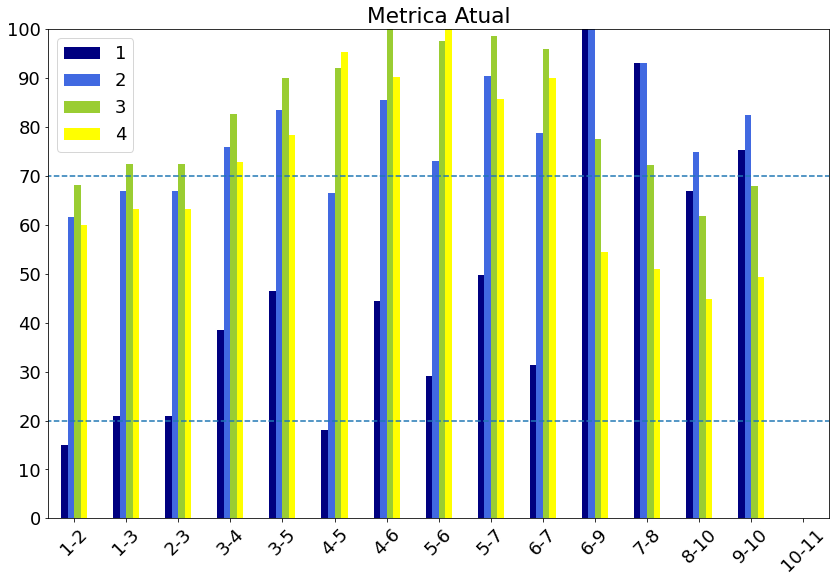

In [31]:
df = le_cfbs()
faz_plot(df, "Metrica Atual")

In [60]:
df = pd.read_csv("../tempos.csv", index_col=0)
df

,Metodo,Grafo,k=1,k=2,k=3,k=4
0,Ex,11 bus,2.685,5.736,13.257,2.243600e+01
1,Ex,39 bus,31.538,483.200,4836.000,2.862900e+04
2,Ex,57 bus,140.541,6376.000,153886.000,2.882565e+06
3,Ex,118 bus,7044.000,142727.000,2892857.000,5.862990e+07
4,DE,11 bus,46.158,38.709,28.644,1.647100e+01
5,DE,39 bus,694.481,458.125,263.438,1.423410e+02
6,DE,57 bus,4494.000,6110.000,6076.000,6.298000e+03
7,DE,118 bus,42.922,22049.000,21504.000,3.258600e+04
8,Gr,11 bus,1.868,2.338,2.757,3.022000e+00
9,Gr,39 bus,29.322,55.407,75.315,9.628200e+01


In [46]:
def faz_plot_tempos(df: pd.DataFrame,
                    nome: str):
    df_filtrado = df.loc[df["Grafo"] == nome, ["Metodo", "k=1", "k=2", "k=3", "k=4"]]
    _, ax = plt.subplots(figsize=(14,9))
    df_filtrado.plot.bar(rot=0, ax=ax, color={"k=1": "navy", "k=2": "royalblue", "k=3": "yellowgreen", "k=4": "yellow"})
    ax.set_title(nome)
    ax.set_xticklabels(df_filtrado.loc[:, "Metodo"].tolist())
    ax.set_ylabel("Execution Time (ms)")
    plt.yscale("log")
    plt.savefig("tempos.svg")

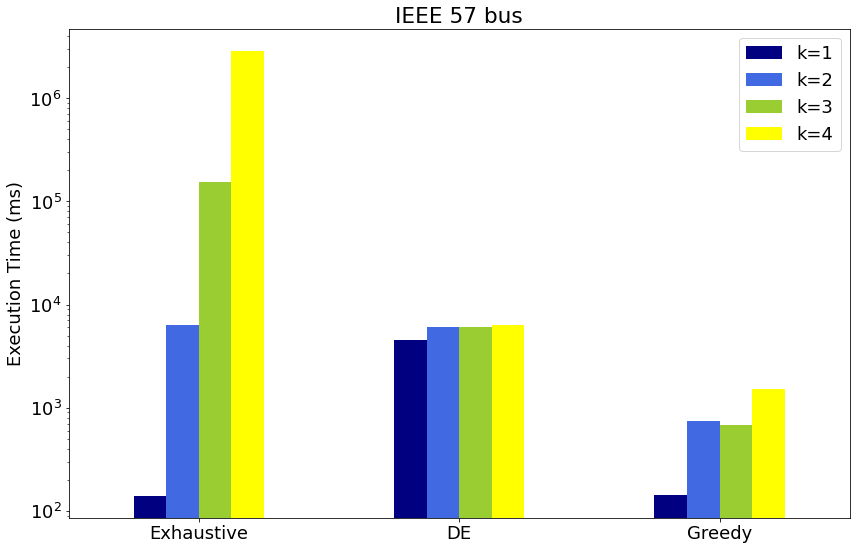

In [47]:
faz_plot_tempos(df, "IEEE 57 bus")

In [145]:
def faz_plot_tempos_completo(df: pd.DataFrame):
    _, ax = plt.subplots(figsize=(16,9))
    dados_df = df.loc[:, ["Metodo-Grafo", "k=1", "k=2", "k=3", "k=4"]]
    dados_df.plot.bar(rot=0, ax=ax, color={"k=1": "navy", "k=2": "royalblue", "k=3": "yellowgreen", "k=4": "yellow"})
    ax.set_xticklabels(dados_df.loc[:, "Metodo-Grafo"].tolist())
    plt.yscale("log")
    # ax.set_yticks([1000, 60000, 3600000])
    # ax.set_yticklabels(["1s", "1min", "1h"])
    ax.set_ylabel("Execution Time (ms)")
    # plt.grid(axis="y", linestyle="--", linewidth=0.5)
    ax.hlines(1000, -1, 15, linestyle="dashed")
    ax.hlines(60000, -1, 15, linestyle="dashed")
    ax.hlines(3600000, -1, 15, linestyle="dashed")
    ax.annotate("1 second", (-0.3, 1e3 + 200))
    ax.annotate("1 minute", (-0.3, 60 * 1e3 + 10000))
    ax.annotate("1 hour", (-0.3, 3600 * 1e3 + 500000))
    plt.savefig("tempos_totais.svg")

In [62]:
df["Metodo-Grafo"] = df["Metodo"] + "\n" + df["Grafo"]

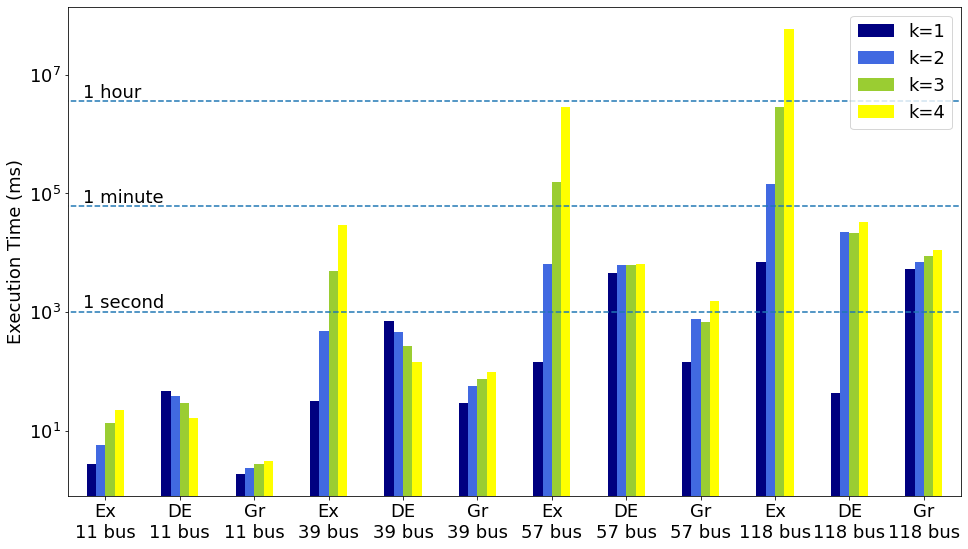

In [146]:
faz_plot_tempos_completo(df)

In [93]:
df["Barras"] = barras



In [95]:
df = df.sort_values("Barras")
df

,Metodo,Grafo,k=1,k=2,k=3,k=4,Metodo-Grafo,Barras
0,Ex,11 bus,2.685,5.736,13.257,2.243600e+01,Ex\n11 bus,11
4,DE,11 bus,46.158,38.709,28.644,1.647100e+01,DE\n11 bus,11
8,Gr,11 bus,1.868,2.338,2.757,3.022000e+00,Gr\n11 bus,11
1,Ex,39 bus,31.538,483.200,4836.000,2.862900e+04,Ex\n39 bus,39
5,DE,39 bus,694.481,458.125,263.438,1.423410e+02,DE\n39 bus,39
9,Gr,39 bus,29.322,55.407,75.315,9.628200e+01,Gr\n39 bus,39
2,Ex,57 bus,140.541,6376.000,153886.000,2.882565e+06,Ex\n57 bus,57
6,DE,57 bus,4494.000,6110.000,6076.000,6.298000e+03,DE\n57 bus,57
10,Gr,57 bus,141.197,748.568,672.631,1.531000e+03,Gr\n57 bus,57
3,Ex,118 bus,7044.000,142727.000,2892857.000,5.862990e+07,Ex\n118 bus,118


In [92]:
barras

[11, 11, 11, 118, 118, 118, 39, 39, 39, 57, 57, 57]